In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [5]:
path_salary = "data/salary/Salary_Data.csv"
s_df = pd.read_csv(path_salary, sep=',', encoding='ISO-8859-1')

engine2 = create_engine("sqlite:///data/salary.sqlite")
s_df = s_df.rename(columns={"ï»¿Age": "Age", "Education Level":"Education_Level",
                            "Job Title":"Job", "Years of Experience":"Years_of_Experience"})

s_df.to_sql("salary", engine2, index=False, if_exists="replace")


6704

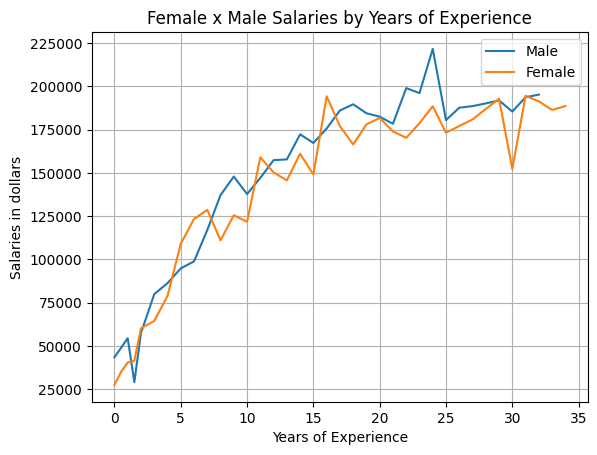

In [3]:
males = pd.read_sql("""SELECT Years_of_Experience, AVG(Salary)
                     FROM salary WHERE Gender = 'Male'
                     GROUP BY Years_of_Experience""", engine2)

females = pd.read_sql("""SELECT Years_of_Experience, AVG(Salary)
                     FROM salary WHERE Gender = 'Female'
                     GROUP BY Years_of_Experience""", engine2)

plt.plot(males['Years_of_Experience'], males['AVG(Salary)'])
plt.plot(females['Years_of_Experience'], females['AVG(Salary)'])
plt.title("Female x Male Salaries by Years of Experience")
plt.ylabel("Salaries in dollars")
plt.xlabel("Years of Experience")
plt.legend(['Male', 'Female'])
plt.grid(True)

<Axes: title={'center': 'Top 10 jobs with biggest salary mean'}>

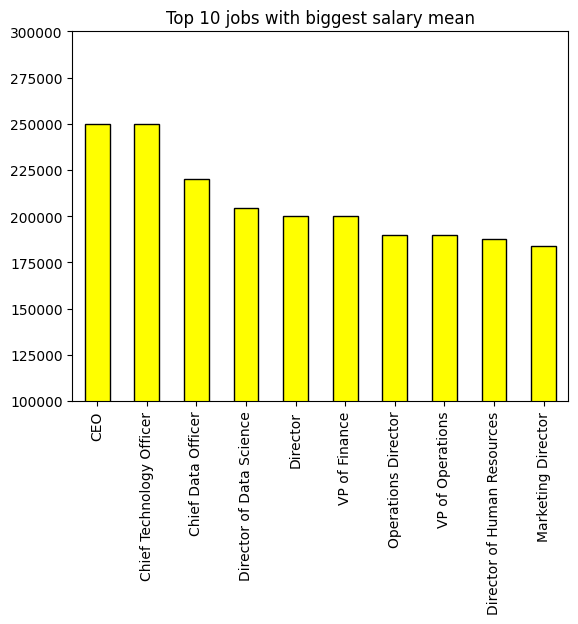

In [21]:
top10_jobs = s_df.groupby(['Job'])['Salary'].mean()
top10_jobs = top10_jobs.sort_values(ascending=False)[0:10]

top10_jobs.plot(kind='bar', edgecolor='black', title="Top 10 jobs with biggest salary mean",
                color="yellow", ylim=(100000, 300000), xlabel="")